# 02_datacheck.ipynb 概要

このファイルは「01_src_sql/00_CsvCreate.sql（実データ）」または「03_notebooks/01_generate_dummy.ipynb」にて生成した"data/01out_individual_raw.csv"を可視化する。

※新たなフィールド生成は特に行わない。ダミーについては 年齢区分 を01 で生成済みだが、実データのみ区分生成を追加で処理する。

## import 
data/01out_individual_raw.csv

## output
04_datacheck/
- fig0_課税・非課税分布.png
- fig1_給与収入_hist.png
- fig1_雑収入_公的年金等_hist.png
- fig1_年税額_hist.png
- fig2_heatmap_Top10andBottom10.png
- fig3_給与収入_年齢区分×性別_boxplot.png
- fig3_雑収入_公的年金等_年齢区分×性別_boxplot.png
- fig3_年税額_年齢区分×性別_boxplot.png
- fig4_給与収入vs給与所得_barplot.png
- fig5_事業所得_不動産所得_分離課税_yearly.png
- fig6_scatter_給与収入and年税額.png
- fig6_scatter_雑収入_公的年金等and年税額.png
- fig7_scatter_給与収入and寄附金税額控除.png
- fig7_scatter_給与収入and住宅借入金特別控除.png
- fig7_scatter_課税標準額and寄附金税額控除.png
- fig7_scatter_課税標準額and住宅借入金特別控除.png
- fig8_1_定額減税_年度別.png
- fig8_2_定額減税_年齢区分×性別_合計.png / _平均.png
- fig8_3_定額減税_年齢区分別推移_合計.png / _平均.png

※ 2026-09-13 整理: fig1のlogヒストグラム・fig4のbarplot・fig5の全体heatmapを削除し、fig5-2→fig2、fig9→fig4、旧fig4→fig5に改番（分離課税の合計を追加）。fig0・fig8の出力名を日本語化。


---

# ディレクトリ設定
03_notebooks/ から実行してもプロジェクトルート基準の相対パス（data/, tax_reform, 04_datacheck/）が解決できるよう、カレントディレクトリをルートへ戻す

output フォルダをSAVE_DIRで指定

In [1]:
import os
import sys
if os.path.basename(os.getcwd()) == "03_notebooks":
    os.chdir("..")
# config.py / tax_reform.py はこのノートブックと同じ 03_notebooks/ にあるため、
# ルートへchdirした後もそこを参照できるよう sys.path に追加する（2026-09-12変更）
sys.path.insert(0, os.path.join(os.getcwd(), "03_notebooks"))
    
SAVE_DIR = "04_datacheck"

---

# ライブラリインポート

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from tax_reform import compute_income_tax_rate

print("Python version:", sys.version)

Python version: 3.14.4 (main, Apr 14 2026, 14:30:57) [MSC v.1944 64 bit (AMD64)]


---


# データ読み込み

In [3]:
df = pd.read_csv("data/01out_individual_raw.csv", encoding="utf-8-sig")
df.head()
print(df.columns)
print(df.dtypes)
print(f"読込完了: {len(df):,} 件 / {df['年度'].nunique()} 年分")

print(df['性別'].unique(), df['年齢区分'].unique())

Index(['仮ID', '年度', '性別', '年齢', '年齢区分', '給与収入', '雑収入_公的年金等', '給与所得',
       '事業所得_営業等', '事業所得_農業', '不動産所得', '利子所得', '配当所得', '雑所得_公的年金等', '雑所得_業務',
       '雑所得_その他', '総合短期譲渡所得', '総合長期譲渡所得', '一時所得', '分離_短期譲渡一般', '分離_短期譲渡軽減',
       '分離_長期譲渡一般', '分離_長期譲渡特定', '分離_長期譲渡軽減', '分離_一般株式譲渡', '分離_特定株式譲渡',
       '分離_上場株式配当', '分離_先物取引', '分離_山林', '社会保険料控除', '小規模企業共済等掛金控除', '生命保険料控除',
       '地震保険料控除', '雑損控除', '医療費控除', '障害者控除', '寡婦控除', '配偶者控除', '配偶者特別控除', '扶養控除',
       '基礎控除', '勤労学生控除', '寄附金控除', '扶養人数', '課税標準額', '住宅借入金特別控除', '寄附金税額控除',
       '調整控除', '配当控除', '外国税額控除', '配当割額・株式等譲渡所得割額の控除', '年税額', '徴収区分', '市町村_均等割',
       '市町村_所得割', '都道府県_均等割', '都道府県_所得割', '控除不足額'],
      dtype='str')
仮ID                  int64
年度                   int64
性別                   int64
年齢                   int64
年齢区分                   str
給与収入                 int64
雑収入_公的年金等            int64
給与所得                 int64
事業所得_営業等             int64
事業所得_農業              int64
不動産所得                int64
利子所得                 int

---

# fig0 : 課税・非課税分布（年度別人数）
年税額が0円（非課税）か0円以外（課税）かの人数を年度別に比較する。

In [4]:
# --- fig0 : 課税・非課税分布（年度別） 2026-09-09追加 -------------------------------------
def plot_taxable_ratio_by_year(df, show: bool = False):
    """
    年税額 が 0円（非課税）か非0円（課税）かの人数を年度別に棒グラフで比較する。
    """
    years = sorted(df["年度"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        df_year = df[df["年度"] == year]
        counts = [
            (df_year["年税額"] == 0).sum(),
            (df_year["年税額"] != 0).sum(),
        ]
        # 2026-09-13変更: 非課税/課税を色分けし、数値ラベルが枠と重ならないよう上に15%の余白を取る
        axes[i].bar(["非課税", "課税"], counts, color=["#9e9e9e", "#1f77b4"])
        axes[i].set_ylim(0, max(counts) * 1.15)
        axes[i].set_title(f"{year}年度")
        axes[i].set_ylabel("人数")
        for j, c in enumerate(counts):
            axes[i].text(j, c, f"{c:,}", ha="center", va="bottom")

    fig.suptitle("課税・非課税分布（年度別人数）")

    plt.tight_layout()
    # 2026-09-13変更: 出力名を日本語化
    path = os.path.join(SAVE_DIR, "fig0_課税・非課税分布.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig0_課税・非課税分布.png


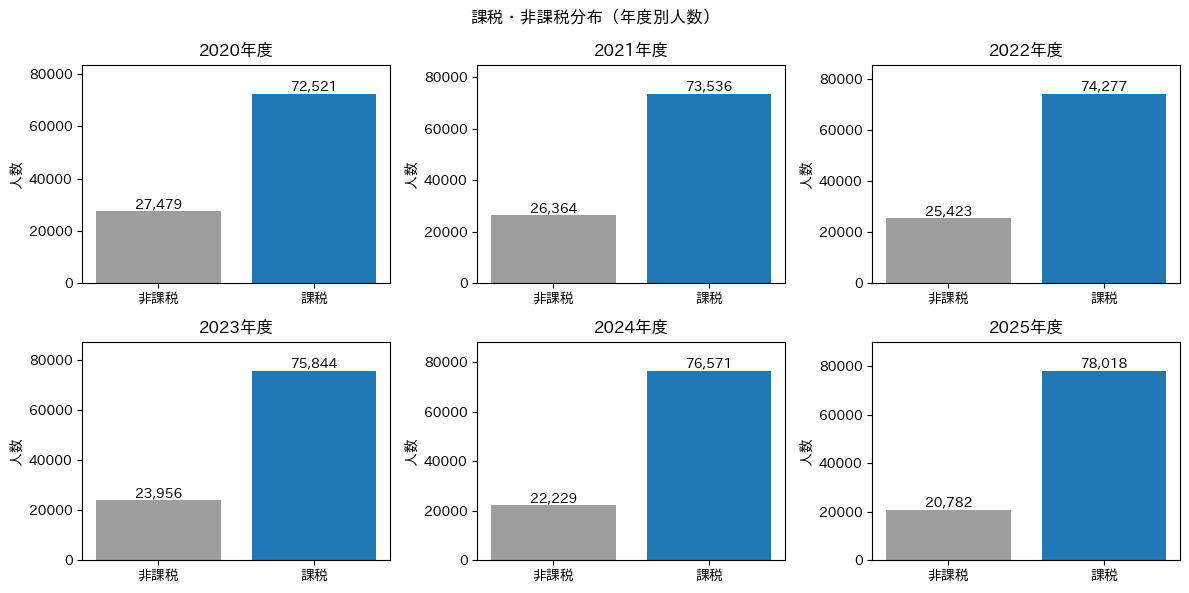

In [5]:
plot_taxable_ratio_by_year(df, show=True)

---


# fig1 : histgram 
給与収入、年金収入、税額の分布

In [6]:
# --- fig1 : histgram -------------------------------------------------------------------
def plot_hist_by_year(df, col, show: bool = False): # , xticks, xlabels
    """
    col     : 列名（例："税額"）
    xticks  : 目盛りの値リスト
    xlabels : 目盛りのラベルリスト"1000万"]）
    """
    years = sorted(df["年度"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        df_year = df[(df["年度"] == year) & (df[col] > 0)]
        axes[i].hist(df_year[col], bins=50)
        axes[i].set_title(f"{year}年度")
        axes[i].set_xlabel(f"{col}")
        axes[i].set_ylabel("人数")


    fig.suptitle(f"{col} ヒストグラム")

    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"fig1_{col}_hist.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig1_給与収入_hist.png


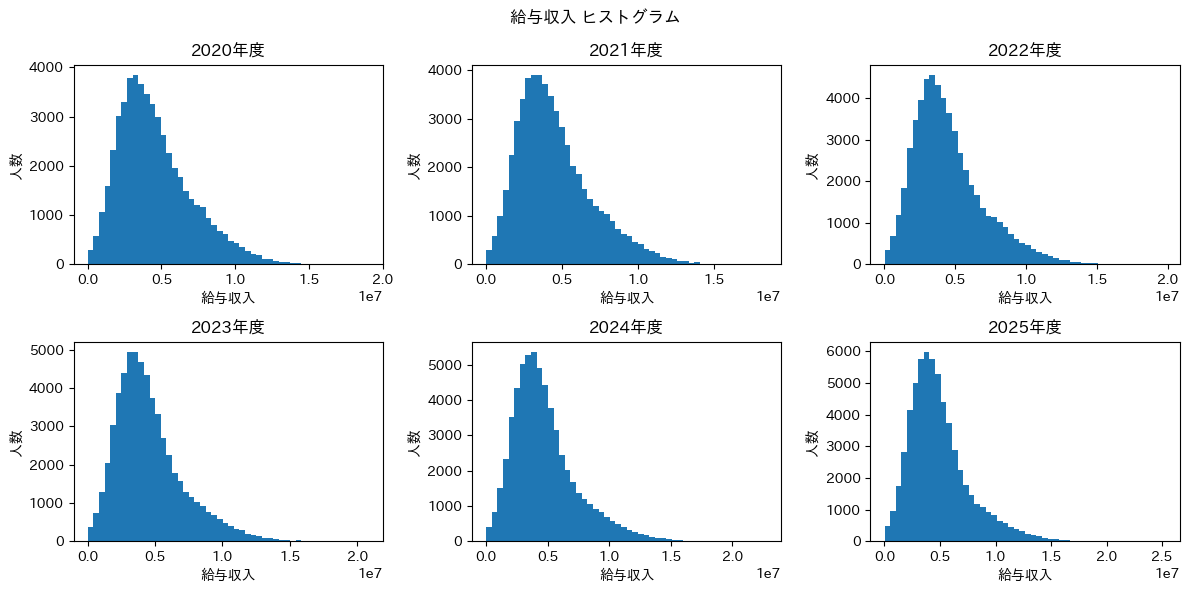

  → 04_datacheck\fig1_雑収入_公的年金等_hist.png


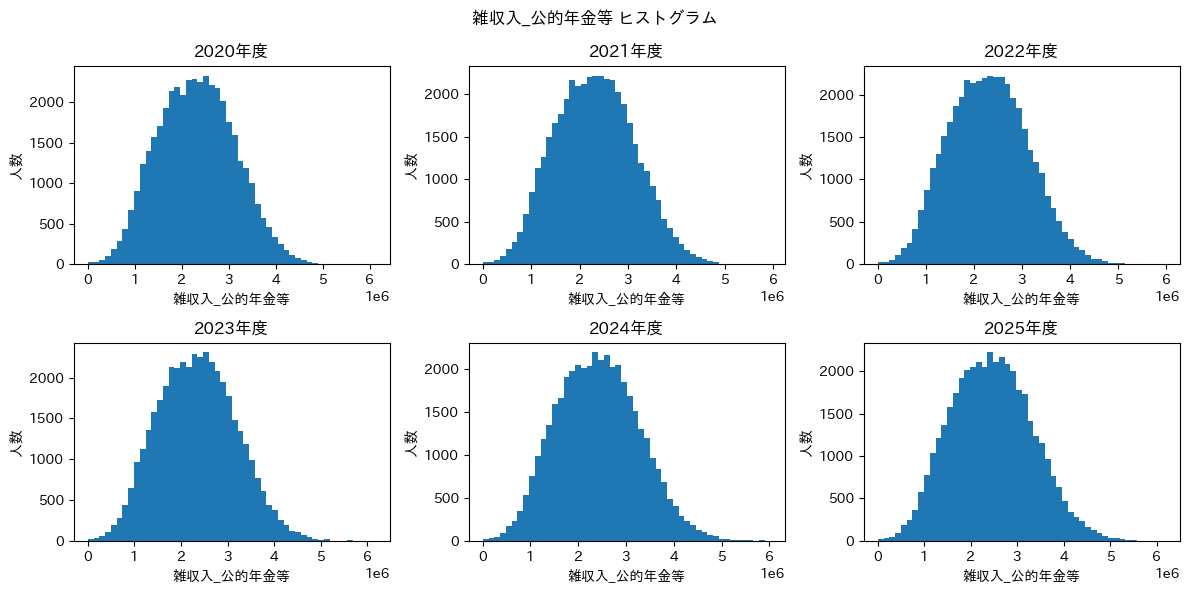

  → 04_datacheck\fig1_年税額_hist.png


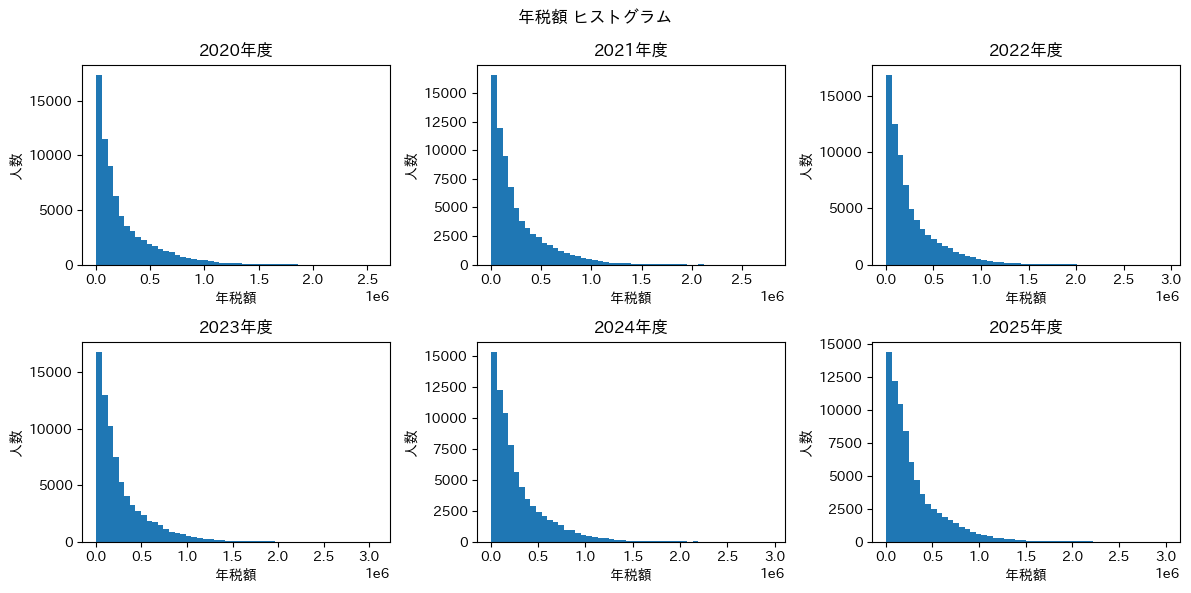

In [7]:
plot_hist_by_year(df, "給与収入", show=True)
plot_hist_by_year(df, "雑収入_公的年金等", show=True)
plot_hist_by_year(df, "年税額", show=True)

---


# fig2 : heatmap_TopBottom10（年税額との相関 上位10・下位10）
税額の内訳（均等割・所得割・控除不足額）と課税標準額を除いた上で、年税額との相関が高い／低い特徴量を確認する。

In [8]:
def plot_heatmap_TopBottom10(df, figsize=(10, 10), cmap='coolwarm', annot=True, show: bool = False):

    # 2026-09-13変更: 03_feature_eng の LEAK_COLS と同じく税額の内訳列を除外してから相関を取る。
    # 所得割・均等割は年税額の内訳そのもので相関が高いのは当然のため、表示しても情報にならない。
    LEAK_COLS = ["市町村_均等割", "市町村_所得割", "都道府県_均等割", "都道府県_所得割", "控除不足額"]
    corr = (
        df.drop(columns=[c for c in LEAK_COLS if c in df.columns])
        .corr(numeric_only=True)["年税額"]
        # 2026-09-13追加: 課税標準額は年税額の計算に直接使う値で相関が高いのは当然のため除外
        .drop(["年税額", "仮ID", "年度", "課税標準額"])
        .sort_values(ascending=False)
    )
    corr_top_bottom = pd.concat([corr.head(10), corr.tail(10)])

    plt.figure(figsize=figsize)
    sns.heatmap(corr_top_bottom.to_frame(), annot=annot, fmt=".2f", cmap=cmap,
                center=0, linewidths=0.5, cbar=False)
    plt.title("Feature Correlation with Target:Top10 & Bottom10", fontsize=10, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"fig2_heatmap_Top10andBottom10.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig2_heatmap_Top10andBottom10.png


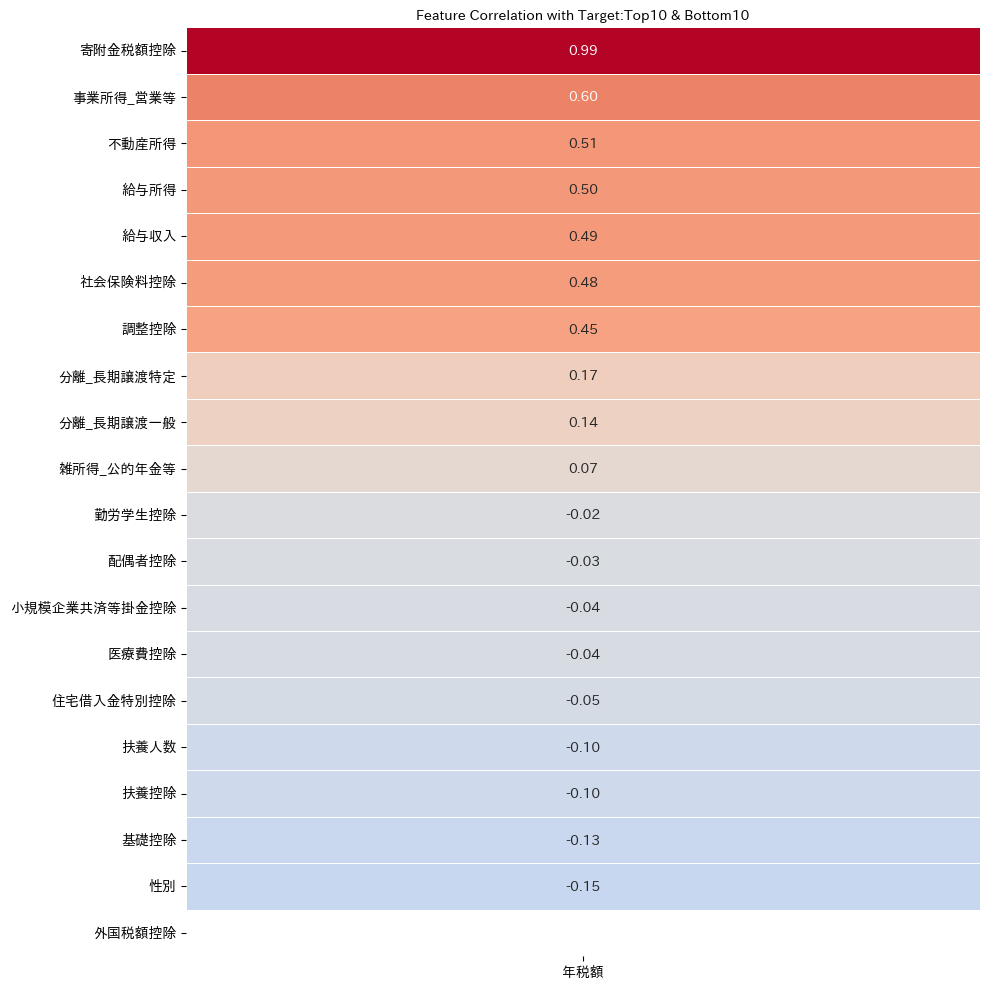

In [9]:
plot_heatmap_TopBottom10(df, show=True)

---


# fig3 : boxplot （給与、年金、税額）
- 年齢区分ごとの分布
- 性別ごとの分布　　
- 年齢区分×性別ごとの分布

In [10]:
# categorical columns
## 年齢区分の順序を定義(昇順)
def _age_order(df):
    """age_group の昇順リストを返す（"90over" / "80以上" も正しく最後に来る）"""
    # 2026-09-12変更: 区分を 80-84/85-89/90over に分割したため "over" 表記にも対応
    return sorted(
        df["年齢区分"].unique(),
        key=lambda x: int(x.replace("以上", "").replace("over", "").split("-")[0])
    )

# 性別カラー定義（男性=青, 女性=ピンク）。gender列のhue分けで共通利用する
GENDER_COLORS = {0: "#1f77b4", 1: "#e84393"}
GENDER_LABELS = {0: "男性", 1: "女性"}

In [11]:
# --- fig3 : boxplot
def boxplot_by_category(df, value_col, category, show: bool = False):
    """
    value_col : 可視化したい列名（例："給与収入"）
    category  : "年齢区分" / "性別" / "both" のいずれか
    """

    df_nonzero = df[df[value_col] > 0].copy()

    if category == "年齢区分":
        plt.figure(figsize=(14, 5))
        sns.boxplot(
            data=df_nonzero,
            x="年齢区分",
            y=value_col,
            order=_age_order(df_nonzero),
            showfliers=False
        )
        plt.xticks(rotation=45)
        plt.title(f"{value_col}　年齢区分別")
        plt.tight_layout()
        path = os.path.join(SAVE_DIR, f"fig3_{value_col}_年齢区分別_boxplot.png")
        plt.savefig(path, dpi=150)
        print(f"  → {path}")
        if show:
            plt.show()
        plt.close()


    elif category == "性別":
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            data=df_nonzero,
            x="性別",
            y=value_col,
            hue="性別",
            palette=GENDER_COLORS,
            legend=False,
            showfliers=False
        )
        plt.title(f"{value_col}　性別")
        plt.tight_layout()
        path = os.path.join(SAVE_DIR, f"fig3_{value_col}_性別_boxplot.png")
        plt.savefig(path, dpi=150)
        print(f"  → {path}")
        if show:
            plt.show()
        plt.close()

    elif category == "both":
        plt.figure(figsize=(16, 5))
        sns.boxplot(
            data=df_nonzero,
            x="年齢区分",
            y=value_col,
            order=_age_order(df_nonzero),
            hue="性別",
            palette=GENDER_COLORS,
            showfliers=False
        )
        plt.xticks(rotation=45)
        plt.title(f"{value_col}　年齢区分×性別")
        handles, _ = plt.gca().get_legend_handles_labels()
        plt.legend(handles=handles, labels=[GENDER_LABELS[0], GENDER_LABELS[1]], title="性別")
        plt.tight_layout()
        path = os.path.join(SAVE_DIR, f"fig3_{value_col}_年齢区分×性別_boxplot.png")
        plt.savefig(path, dpi=150)
        print(f"  → {path}")
        if show:
            plt.show()
        plt.close()

    else:
        print("categoryは '年齢区分' / '性別' / 'both' のいずれかを指定してください")

  → 04_datacheck\fig3_給与収入_年齢区分×性別_boxplot.png


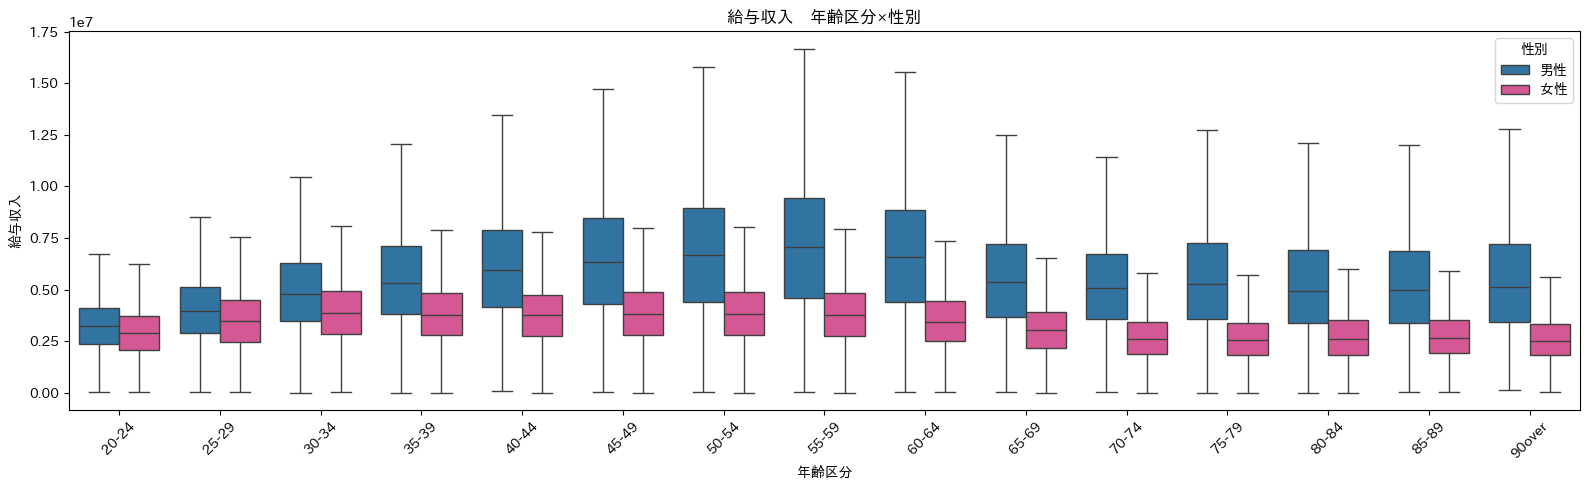

  → 04_datacheck\fig3_雑収入_公的年金等_年齢区分×性別_boxplot.png


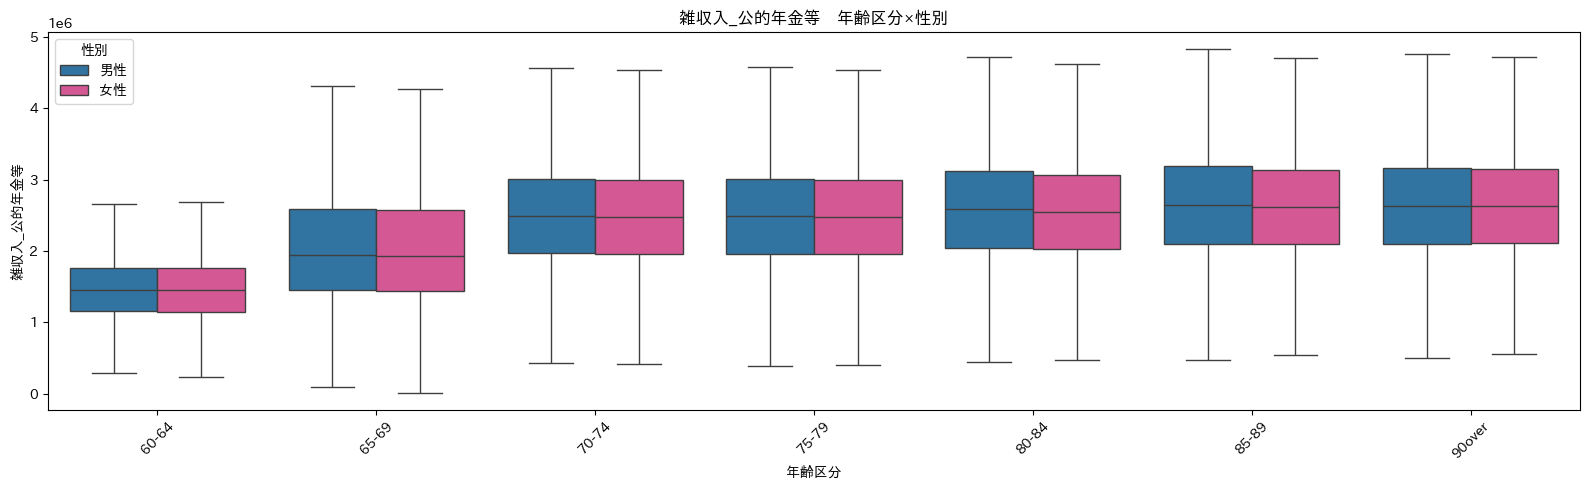

  → 04_datacheck\fig3_年税額_年齢区分×性別_boxplot.png


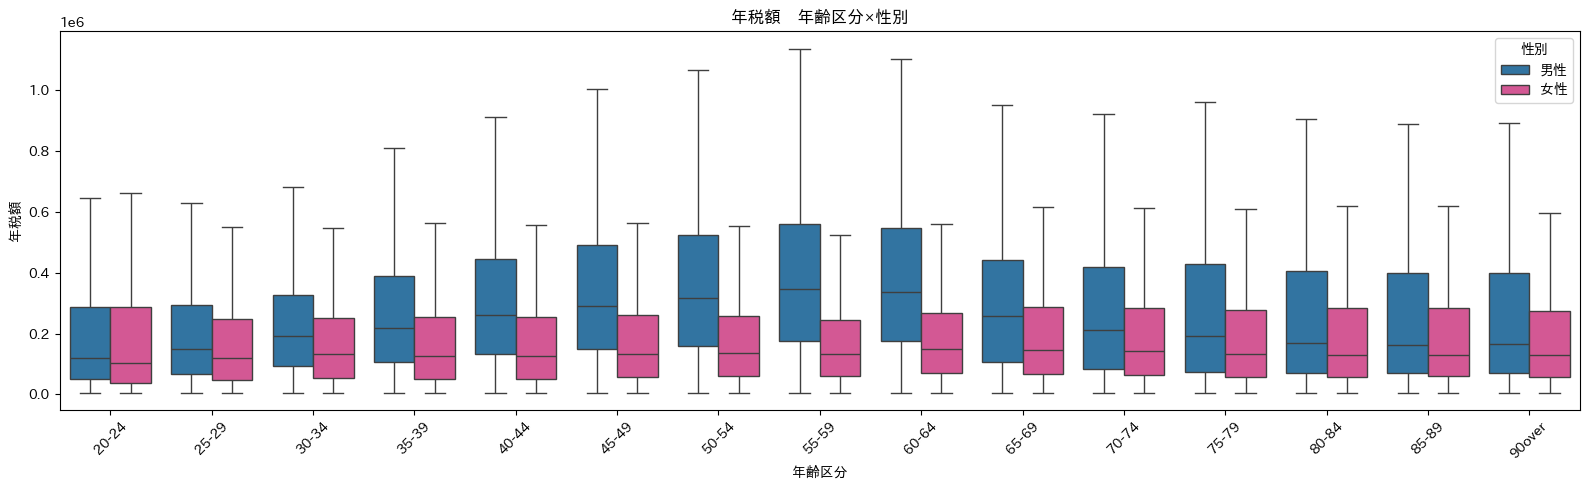

In [12]:
## 給与収入を年齢×性別で区分
boxplot_by_category(df, "給与収入", "both", show=True)
## 年金収入を年齢×性別で区分
boxplot_by_category(df, "雑収入_公的年金等", "both", show=True)
## 税額を年齢×性別で区分
boxplot_by_category(df, "年税額", "both", show=True)

---


# fig4 : 給与収入と給与所得の年度推移（税制改正前後の比較）
給与収入と給与所得（給与所得控除後）を年度別に並べ、合計（左）と平均（右）で比較する。

In [13]:
# --- fig4 : 給与収入と給与所得の年度推移（税制改正前後の比較） 2026-09-13 fig9から移動
def plot_salary_income_yearly(df, gross_col="給与収入", net_col="給与所得",
                              show : bool = False):
    """
    gross_col : 給与収入合計の列名
    net_col   : 給与所得合計の列名
    x軸=year、給与収入と給与所得を隣り合わせのバーで表示する。
    左に合計、右に平均を並べて表示する（同一条件）。
    """
    df_long = df.melt(
        id_vars=["年度"],
        value_vars=[gross_col, net_col],
        var_name="種別", value_name="金額",
    )
    df_long["種別"] = df_long["種別"].map({gross_col: "給与収入", net_col: "給与所得"})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    for ax, estimator, label_agg in zip(axes, [np.sum, np.mean], ["合計", "平均"]):
        sns.barplot(
            data=df_long,
            x="年度", y="金額", hue="種別",
            estimator=estimator,
            ax=ax,
        )
        ax.set_title(f"給与収入・給与所得の年度推移（{label_agg}）")
        ax.set_xlabel("年度")
        ax.set_ylabel(f"金額（円・{label_agg}）")

    plt.tight_layout()
    path = os.path.join(SAVE_DIR, "fig4_給与収入vs給与所得_barplot.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig4_給与収入vs給与所得_barplot.png


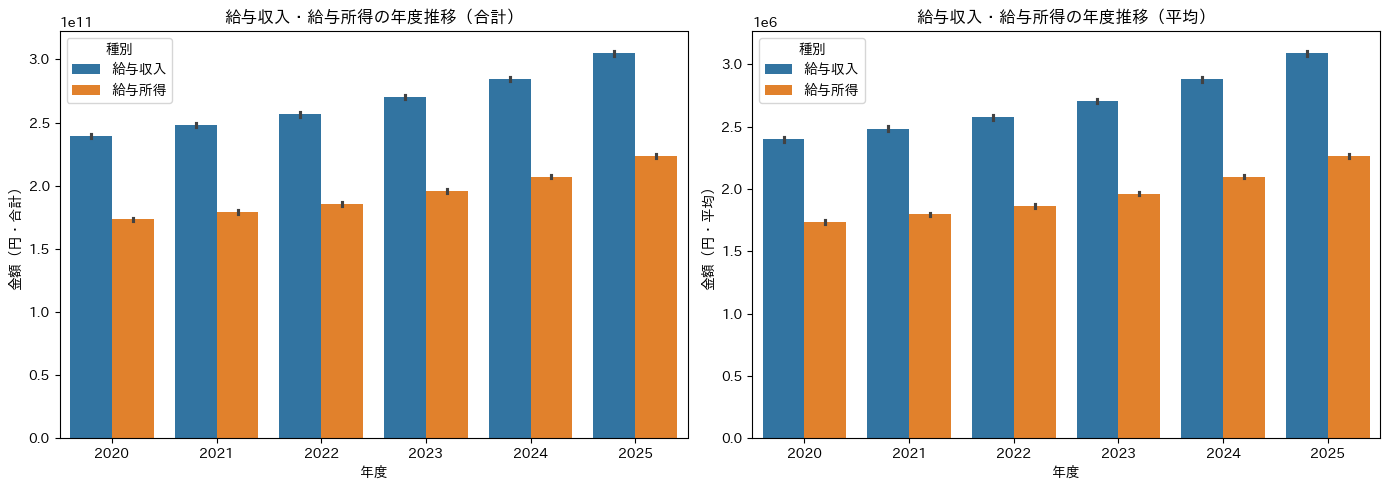

In [14]:
plot_salary_income_yearly(df, show=True)

---

# fig5 : 事業所得（営業等）・不動産所得・分離課税所得の年度推移
所得の種類ごとに、所得合計（億円）の年度推移を折れ線で確認する。分離課税所得は「分離_」で始まる全列の合計。

In [15]:
# --- fig5 : 事業所得（営業等）・不動産所得・分離課税所得の年度推移 2026-09-13追加（同日 fig4→fig5、分離課税の合計を追加）
def plot_income_total_by_year(df, cols=("事業所得_営業等", "不動産所得"), include_sep: bool = True,
                              show: bool = False):
    """
    所得の種類ごとに所得合計（億円）を年度推移の折れ線で表示する。
    cols        : 表示したい所得列（既定: 事業所得_営業等・不動産所得）
    include_sep : True なら分離課税所得（列名が「分離_」で始まる全列）の合計も同じ図に描く
    """
    cols = list(cols)
    yearly = df.groupby("年度")[cols].sum() / 1e8
    if include_sep:
        sep_cols = [c for c in df.columns if c.startswith("分離_")]
        yearly["分離課税所得（合計）"] = df.groupby("年度")[sep_cols].sum().sum(axis=1) / 1e8

    fig, ax = plt.subplots(figsize=(9, 5))
    for col in yearly.columns:
        ax.plot(yearly.index, yearly[col], marker="o", linewidth=2, label=col)
        for yr, v in yearly[col].items():
            ax.annotate(f"{v:.1f}億", (yr, v), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=8)
    ax.set_xticks(yearly.index)
    ax.set_ylim(0, yearly.values.max() * 1.15)
    ax.set_xlabel("年度")
    ax.set_ylabel("所得合計（億円）")
    ax.set_title("・".join(yearly.columns) + "　所得合計の年度推移")
    ax.grid(axis="y", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    path = os.path.join(SAVE_DIR, "fig5_事業所得_不動産所得_分離課税_yearly.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig5_事業所得_不動産所得_分離課税_yearly.png


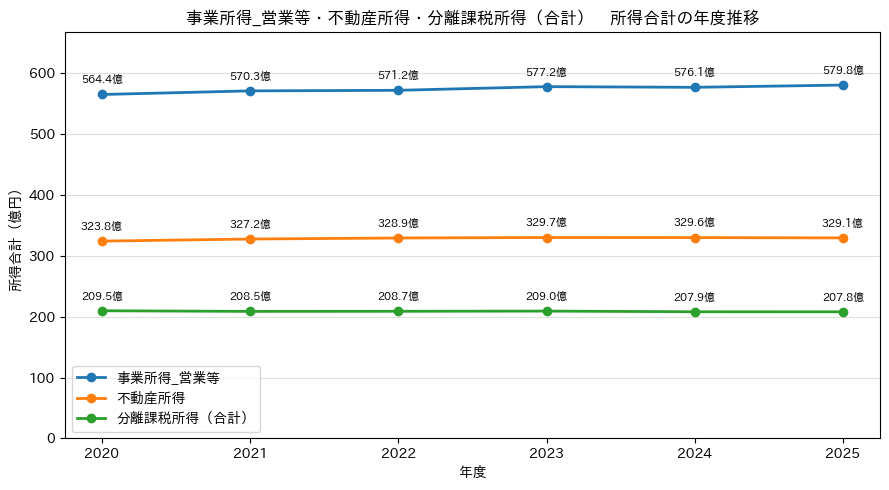

In [16]:
plot_income_total_by_year(df, show=True)

---


# fig6 : 散布図
- 給与 × 税額　---性別毎に色分
- 年金 × 税額　---性別毎に色分

In [17]:
def plot_scatter_by_year(df, x_col, y_col, show: bool = False):
    """
    x_col : x軸にしたい列名（例："給与収入"）
    y_col : y軸にしたい列名（例："税額"）
    """

    years = sorted(df["年度"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        df_year = df[(df["年度"] == year) & (df[x_col] > 0) & (df[y_col] > 0)]

        for gender, color in GENDER_COLORS.items():
            label = GENDER_LABELS[gender]
            df_gender = df_year[df_year["性別"] == gender]
            axes[i].scatter(
                df_gender[x_col],
                df_gender[y_col],
                alpha=0.5,
                c=color,
                label=label
            )

        axes[i].set_title(f"{year}年度")
        axes[i].set_xlabel(x_col)
        axes[i].set_ylabel(y_col)
        axes[i].legend(title="性別",loc="upper left")
    fig.suptitle(f"年度　{x_col} vs {y_col}")
    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"fig6_scatter_{x_col}and{y_col}.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig6_scatter_給与収入and年税額.png


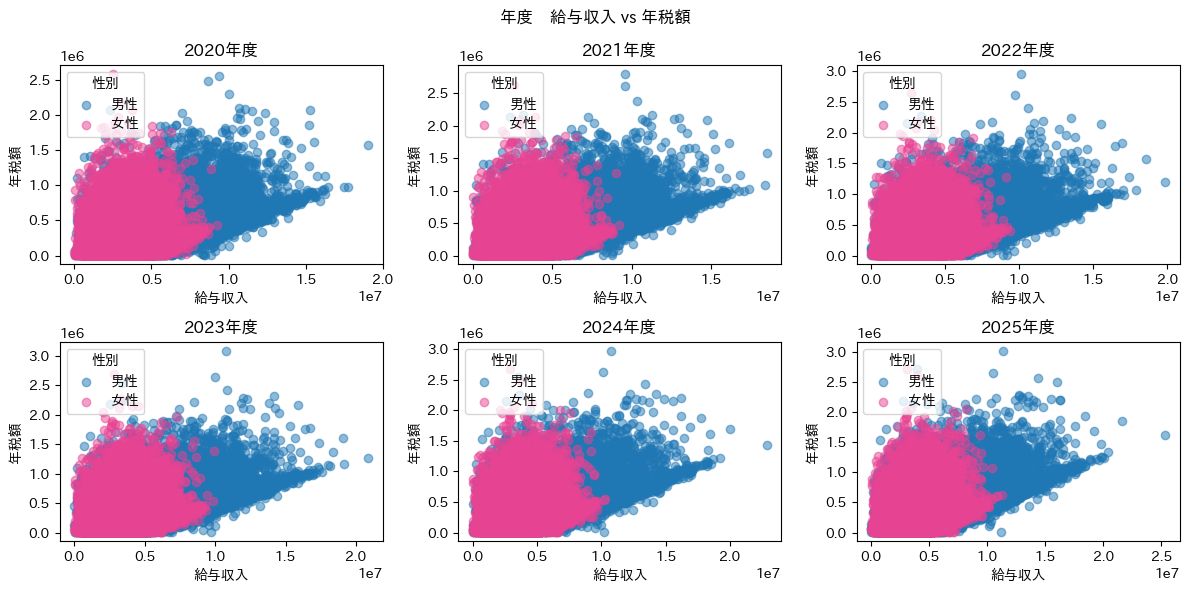

  → 04_datacheck\fig6_scatter_雑収入_公的年金等and年税額.png


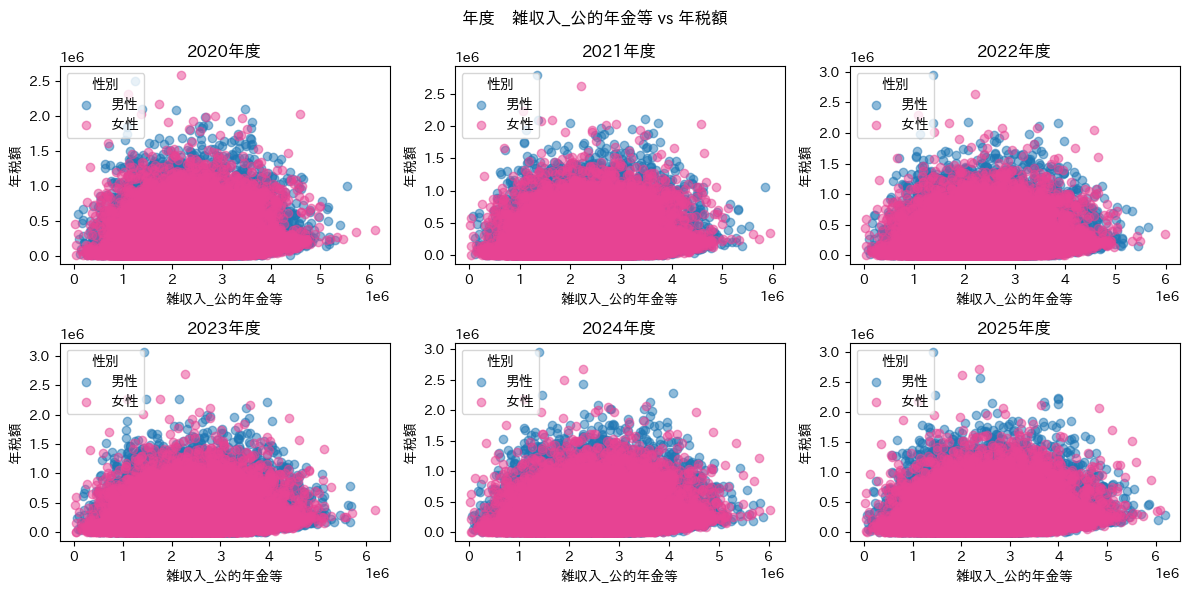

In [18]:
## 給与収入と税額の散布図
plot_scatter_by_year(df, "給与収入", "年税額", show=True)
## 年金収入と税額の散布図
plot_scatter_by_year(df, "雑収入_公的年金等", "年税額", show=True)

---


# fig7 税額控除散布図（所得税率ごとに色分）
- 給与 × ふるさと納税寄付金控除額
- 給与 × 住宅借入金等特別控除額

In [19]:
# 所得税率区分（tax_reform.compute_income_tax_rateのブラケットに対応するラベル）
_TAX_RATE_LABELS = {
    0.05105: "5%",
    0.10210: "10%",
    0.20420: "20%",
    0.23483: "23%",
    0.33693: "33%",
    0.40840: "40%",
    0.45945: "45%",
}
_TAX_BRACKET_ORDER = ["5%", "10%", "20%", "23%", "33%", "40%", "45%"]

def _income_tax_bracket_label(taxable_income):
    """taxable_income から compute_income_tax_rate のブラケットに対応するラベル（"5%"〜"45%"）を返す。"""
    rate = compute_income_tax_rate(np.asarray(taxable_income, dtype=float))
    return np.array([_TAX_RATE_LABELS.get(round(r, 5), "?") for r in rate])


def plot_scatter_by_tax_bracket(df, x_col, y_col, show: bool = False):
    """
    x_col : x軸にしたい列名（例："給与収入"）
    y_col : y軸にしたい列名（例："寄附金税額控除"）
    taxable_income から算出した所得税率区分（5%〜45%）で色分けし、年度別に表示する。
    """
    years  = sorted(df["年度"].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(_TAX_BRACKET_ORDER)))

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()

    for i, year in enumerate(years):
        df_year = df[(df["年度"] == year) & (df[x_col] > 0) & (df[y_col] > 0)].copy()
        df_year["tax_bracket"] = _income_tax_bracket_label(df_year["課税標準額"])

        for bracket, color in zip(_TAX_BRACKET_ORDER, colors):
            df_b = df_year[df_year["tax_bracket"] == bracket]
            if df_b.empty:
                continue
            axes[i].scatter(
                df_b[x_col], df_b[y_col],
                alpha=0.3, s=6, c=[color],
                label=bracket if i == 0 else None
            )

        axes[i].set_title(f"{year}年度", fontsize=9)
        axes[i].set_xlabel(x_col, fontsize=8)
        axes[i].set_ylabel(y_col, fontsize=8)

    fig.suptitle(f"{x_col} vs {y_col}（所得税率区分別）")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="所得税率区分", loc="upper right", fontsize=7)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    path = os.path.join(SAVE_DIR, f"fig7_scatter_{x_col}and{y_col}.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig7_scatter_給与収入and寄附金税額控除.png


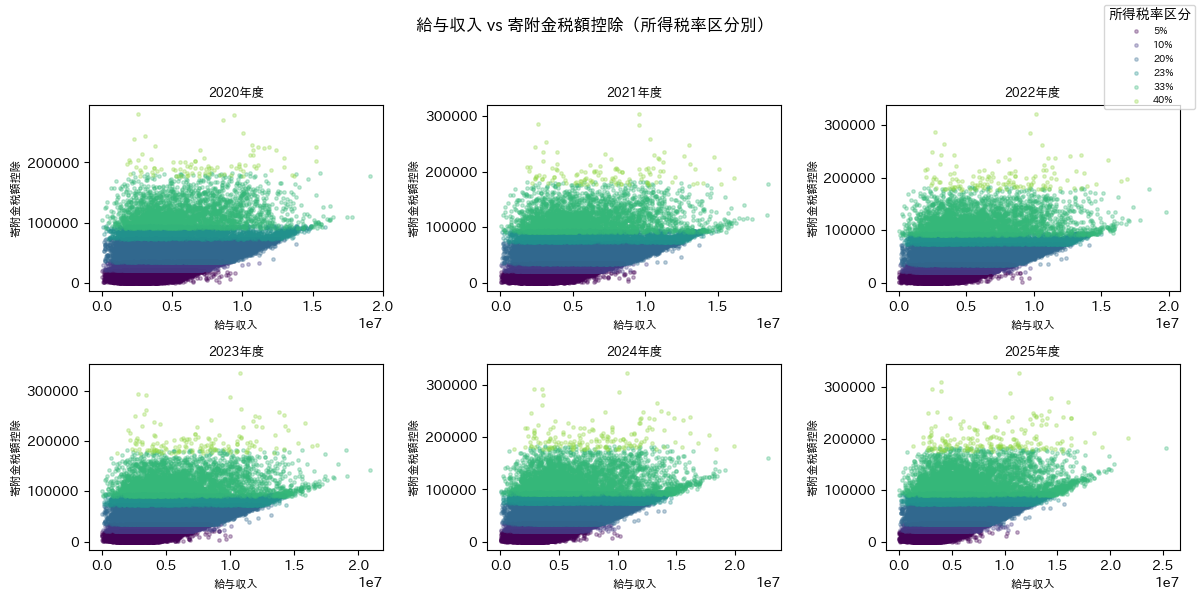

  → 04_datacheck\fig7_scatter_給与収入and住宅借入金特別控除.png


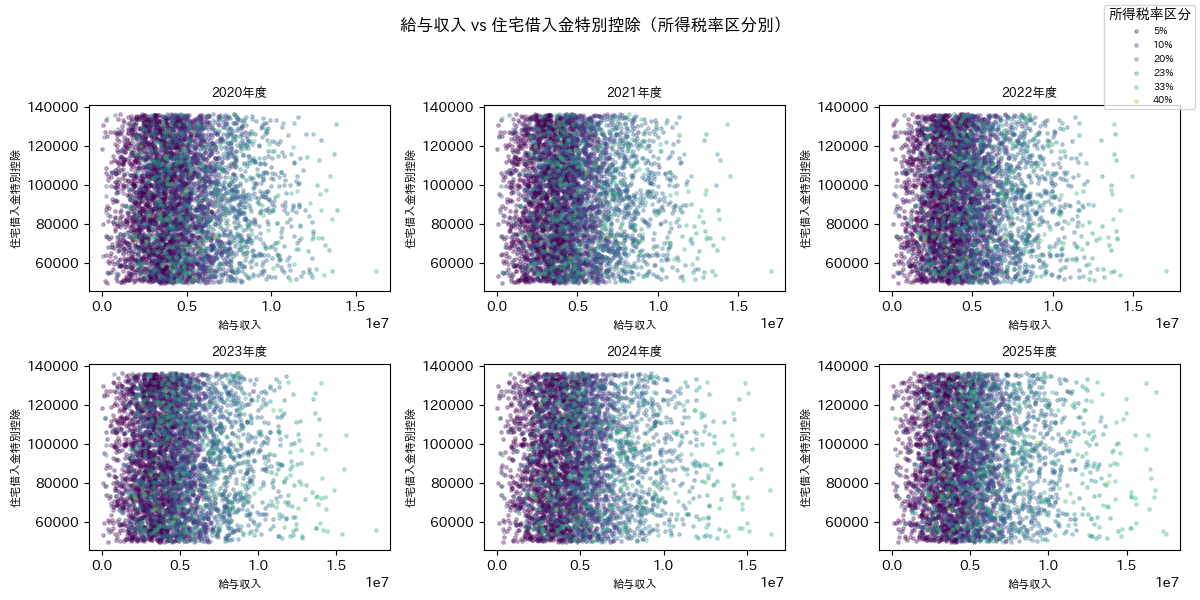

  → 04_datacheck\fig7_scatter_課税標準額and寄附金税額控除.png


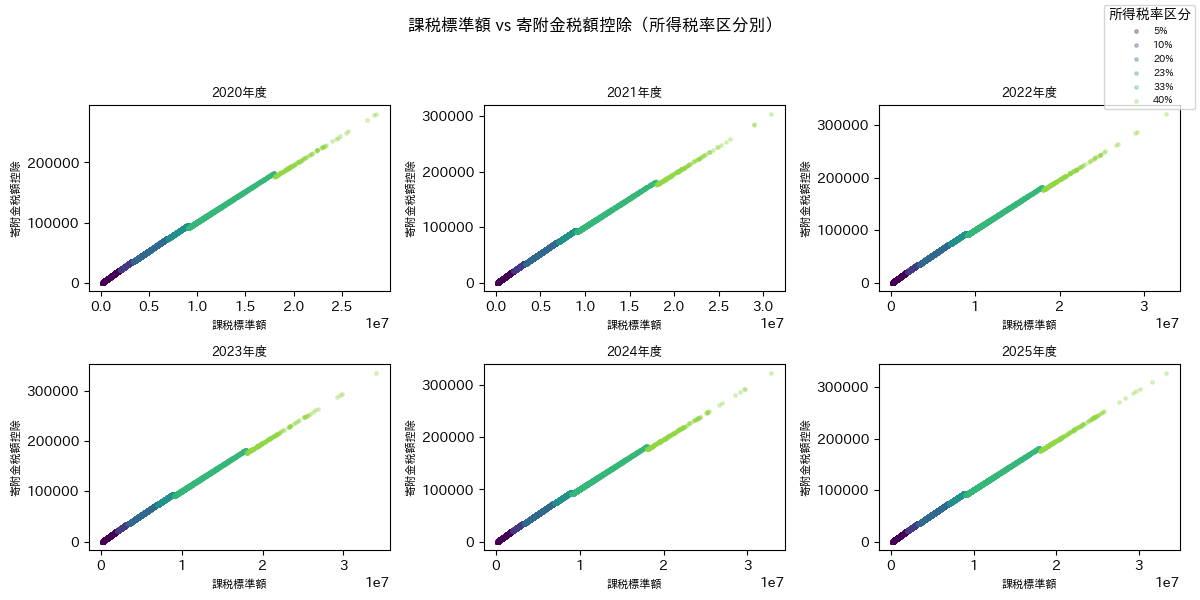

  → 04_datacheck\fig7_scatter_課税標準額and住宅借入金特別控除.png


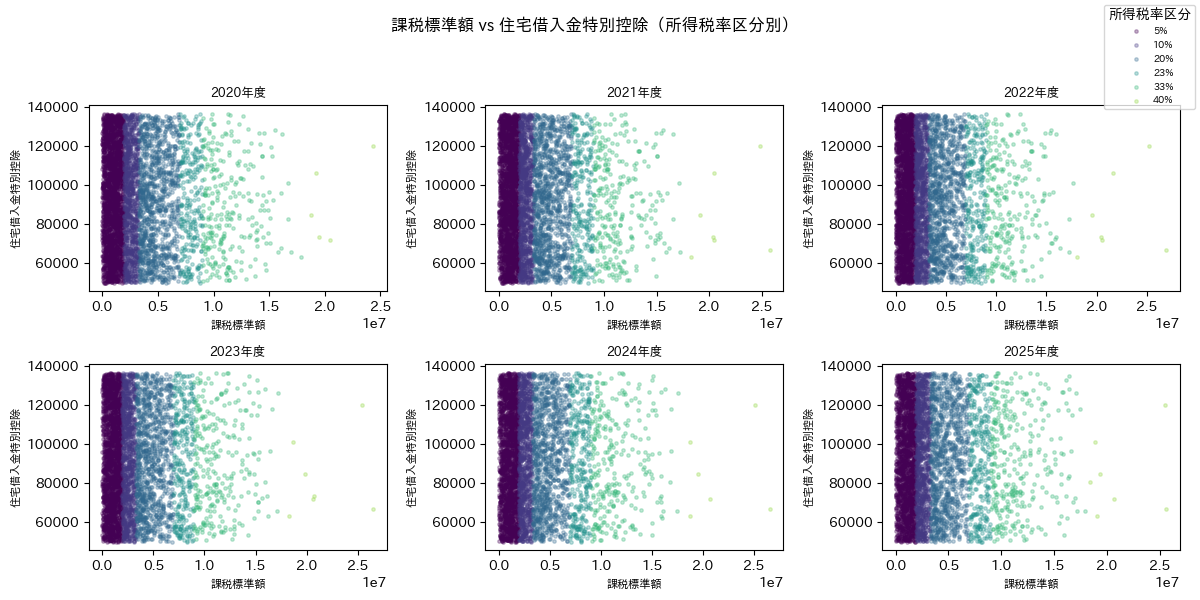

In [20]:
## 給与収入とふるさと納税控除額の散布図（所得税率区分で色分け）
plot_scatter_by_tax_bracket(df, "給与収入", "寄附金税額控除", show=True)
## 給与収入と住宅借入金特別控除額の散布図（所得税率区分で色分け）
plot_scatter_by_tax_bracket(df, "給与収入", "住宅借入金特別控除", show=True)
## 税額とふるさと納税控除額の散布図（所得税率区分で色分け）
plot_scatter_by_tax_bracket(df, "課税標準額", "寄附金税額控除", show=True)
## 税額と住宅借入金特別控除額の散布図（所得税率区分で色分け）
plot_scatter_by_tax_bracket(df, "課税標準額", "住宅借入金特別控除", show=True)

---


# fig8 定額減税影響可視化
実データでは「定額減税控除額」「年税額（減税額足す前）」をそのまま抽出できる想定。
年税額（現状値）= 年税額（減税額足す前）+ 定額減税控除額 という関係。
ダミーデータには当該列がないため、住民税の定額減税ルール（本人1万円＋扶養親族等1人につき1万円、2024年度）で仮の値をモック生成する。

In [21]:
def mock_teigaku_reduction(df, reduction_years=(2024,2025), amount_per_person=10_000):
    """
    year が reduction_years に含まれ、tax_amount > 0 の人に定額減税控除額を仮設定し、
    以下2列を追加する（実データ投入後はこの関数は不要になる想定）。
      teigaku_reduction           : 定額減税控除額（仮）
      tax_amount_before_reduction : tax_amount（減税額足す前）（仮）
    """
    df = df.copy()
    target = df["年度"].isin(reduction_years) & (df["年税額"] > 0)

    reduction = pd.Series(0, index=df.index)
    reduction.loc[target] = amount_per_person * (1 + df.loc[target, "扶養人数"])
    reduction = np.minimum(reduction, df["年税額"])  # 減税額が税額を超えないようクリップ

    df["定額減税額"] = reduction
    df["定額減税前_年税額"] = df["年税額"] - reduction
    return df

In [22]:
df_mock_teigaku = mock_teigaku_reduction(df)

In [23]:
## 税額合計（億円）を年度別に積み上げ棒グラフで表示する関数（定額減税の影響可視化）
def plot_teigaku_reduction_by_year(df, before_col="定額減税前_年税額",
                                    reduction_col="定額減税額",
                                    show: bool = False):
    """
    before_col    : tax_amount（減税額足す前）の列名
    reduction_col : 定額減税控除額の列名
    年度別の税額合計（億円）を、減税額足す前のtax_amountを下・定額減税控除額を上に
    積み上げて表示する（積み上げた合計が現状のtax_amountに一致する）。
    """
    yearly = df.groupby("年度")[[before_col, reduction_col]].sum() / 1e8
    years = yearly.index.tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(years, yearly[before_col], label="tax_amount（減税額足す前）", color="#1f77b4")
    ax.bar(years, yearly[reduction_col], bottom=yearly[before_col],
           label="定額減税控除額", color="#e84393")

    for yr in years:
        total = yearly.loc[yr, before_col] + yearly.loc[yr, reduction_col]
        ax.text(yr, total, f"{total:.1f}億円", ha="center", va="bottom")

    ax.set_xlabel("年度")
    ax.set_ylabel("税額合計（億円）")
    ax.set_title("定額減税の影響（年度別税額推移）")
    ax.set_xticks(years)
    ax.legend()
    plt.tight_layout()
    # 2026-09-13変更: 出力名を日本語化
    path = os.path.join(SAVE_DIR, "fig8_1_定額減税_年度別.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 税収総額のうち、定額減税による減額分の影響を可視化

  → 04_datacheck\fig8_1_定額減税_年度別.png


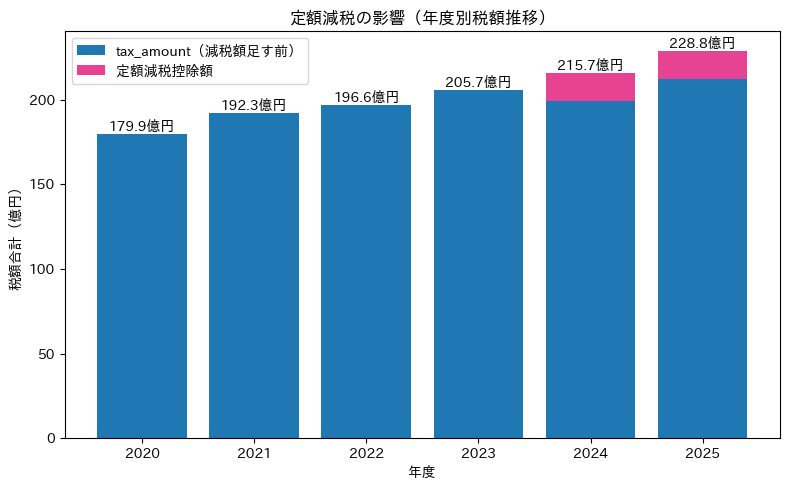

In [24]:
## 年度別の税額合計（億円）を積み上げ棒グラフで表示
plot_teigaku_reduction_by_year(df_mock_teigaku, show=True)

In [25]:
## 税額合計（億円）を年度別 / 年齢区分×性別で積み上げ棒グラフで表示する関数（定額減税の影響可視化）
def plot_teigaku_reduction_by_age_gender(df, before_col="定額減税前_年税額",
                                          reduction_col="定額減税額", agg="sum",
                                          show: bool = False):
    """
    before_col    : tax_amount（減税額足す前）の列名
    reduction_col : 定額減税控除額の列名
    agg           : "sum"（合計） or "mean"（平均）
    年度（6年分）× 年齢区分 × 性別で、減税額足す前のtax_amountを下・定額減税控除額を
    上に積み上げて表示する（性別は色、減税額足す前/控除額はバー内の濃淡で区別）。
    """
    years     = sorted(df["年度"].unique())
    age_order = _age_order(df)
    x         = np.arange(len(age_order))
    width     = 0.35

    gender_settings = [(0, "#1f77b4", "男性"), (1, "#e84393", "女性")]

    # 6サブプロット全てで同一のy軸範囲になるよう設定
    # sharey=True を 465 に追加し、6つのサブプロットのy軸スケールを統一（最大値は6年度中の最大値に自動的に揃う）
    fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharey=True)
    axes = axes.flatten()

    for i, year in enumerate(years):
        ax      = axes[i]
        df_year = df[df["年度"] == year]

        for gi, (gender, color, label) in enumerate(gender_settings):
            grouped = (
                df_year[df_year["性別"] == gender]
                .groupby("年齢区分")[[before_col, reduction_col]]
                .agg(agg)
                .reindex(age_order)
                .fillna(0)
            )
            offset = (gi - 0.5) * width
            ax.bar(x + offset, grouped[before_col], width, color=color, alpha=0.9,
                   label=f"{label}（減税前）" if i == 0 else None)
            ax.bar(x + offset, grouped[reduction_col], width, bottom=grouped[before_col],
                   color=color, alpha=0.4, hatch="//",
                   label=f"{label}（定額減税）" if i == 0 else None)

        ax.set_title(f"{year}年度", fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(age_order, rotation=45, fontsize=6)
        ax.tick_params(axis="y", labelsize=7)

    label_agg = "合計" if agg == "sum" else "平均"
    fig.supylabel(f"税額{label_agg}（円）", fontsize=9)
    fig.suptitle(f"定額減税の影響（年齢区分×性別・{label_agg}）")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=7, ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    # 2026-09-13変更: 出力名を日本語化し、合計/平均を別ファイルにする（従来は同名で平均が合計を上書きしていた）
    path = os.path.join(SAVE_DIR, f"fig8_2_定額減税_年齢区分×性別_{label_agg}.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

## 年齢区分 × 性別ごとの税額の可視化
2024年、2025年については定額減税による減少を斜線バーで表示

  → 04_datacheck\fig8_2_定額減税_年齢区分×性別_合計.png


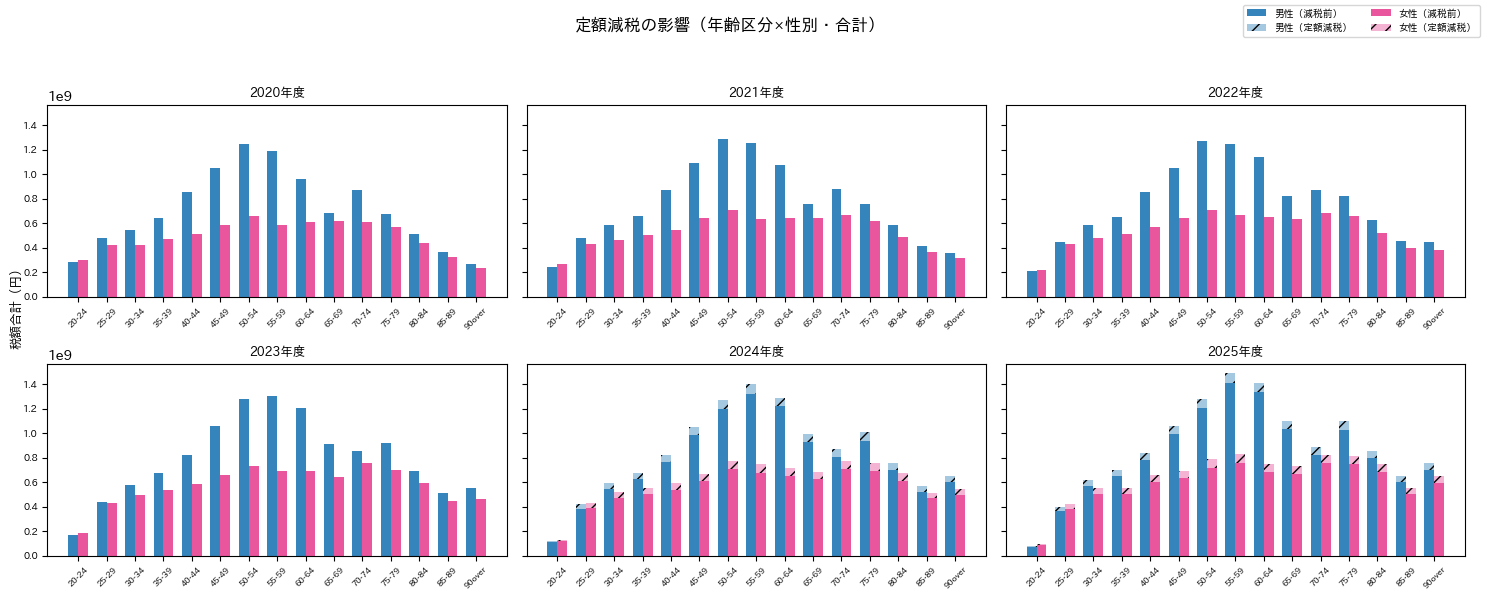

  → 04_datacheck\fig8_2_定額減税_年齢区分×性別_平均.png


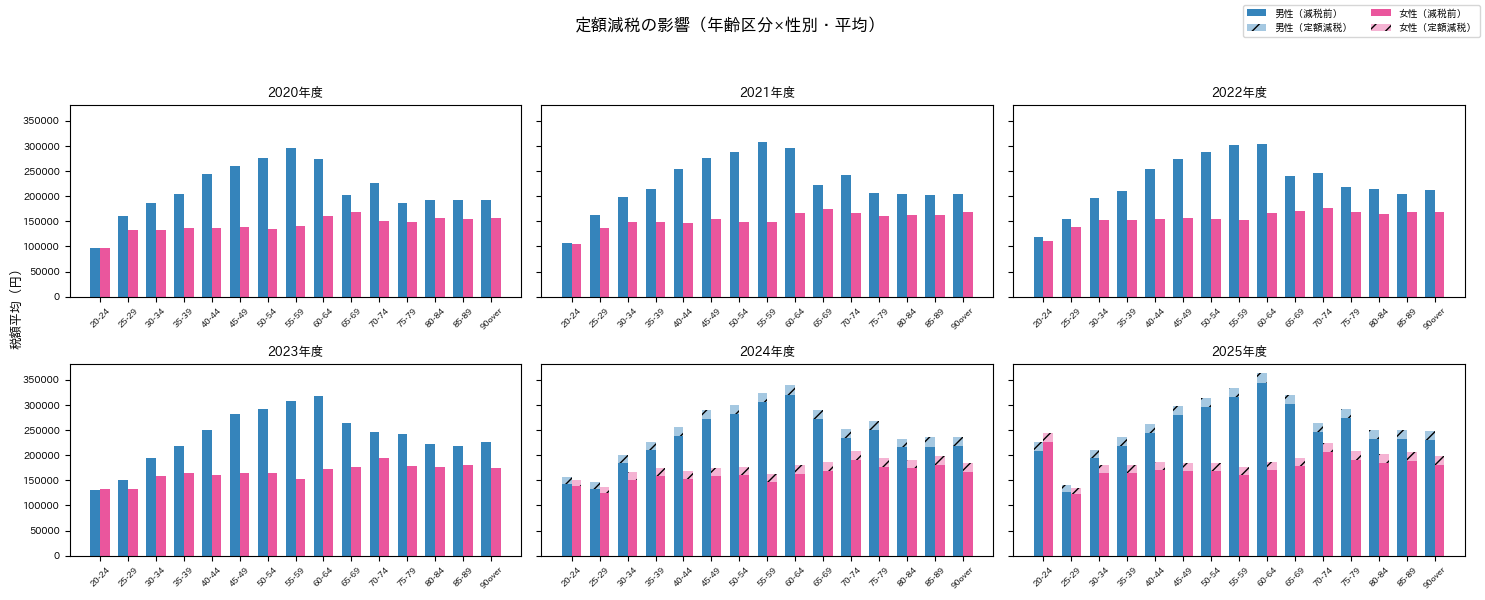

In [26]:
## 年度別の税額合計を年齢区分×性別（合計）で積み上げ棒グラフで表示
plot_teigaku_reduction_by_age_gender(df_mock_teigaku, agg="sum", show=True)
## 年度別の税額合計を年齢区分×性別（平均）で積み上げ棒グラフで表示
plot_teigaku_reduction_by_age_gender(df_mock_teigaku, agg="mean", show=True)

In [27]:
## 税額合計を年齢区分別・年度推移（合計・平均）で積み上げ棒グラフで表示する関数（定額減税の影響可視化）
def plot_teigaku_reduction_yearly_by_age(df, before_col="定額減税前_年税額",
                                          reduction_col="定額減税額", agg="sum",
                                          show: bool = False):
    """
    before_col    : tax_amount（減税額足す前）の列名
    reduction_col : 定額減税控除額の列名
    agg           : "sum"（合計） or "mean"（平均）
    年齢区分ごとにサブプロットを分け（1行3つ）、各サブプロット内はx軸=年度、
    減税額足す前のtax_amountを下・定額減税控除額を上に積み上げて表示する
    （性別は色、減税額足す前/控除額はバー内の濃淡で区別）。
    """
    years     = sorted(df["年度"].unique())
    age_order = _age_order(df)
    x         = np.arange(len(years))
    width     = 0.35

    gender_settings = [(0, "#1f77b4", "男性"), (1, "#e84393", "女性")]

    n_cols = 5
    n_rows = -(-len(age_order) // n_cols)  # 切り上げ（マイナスの切り捨てをマイナスで戻すことで切り上げを実現）

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2 * n_rows), sharey=True)
    axes = axes.flatten()

    for i, age_group in enumerate(age_order):
        ax     = axes[i]
        df_age = df[df["年齢区分"] == age_group]

        for gi, (gender, color, label) in enumerate(gender_settings):
            grouped = (
                df_age[df_age["性別"] == gender]
                .groupby("年度")[[before_col, reduction_col]]
                .agg(agg)
                .reindex(years)
                .fillna(0)
            )
            offset = (gi - 0.5) * width
            ax.bar(x + offset, grouped[before_col], width, color=color, alpha=0.9,
                   label=f"{label}（減税前）" if i == 0 else None)
            ax.bar(x + offset, grouped[reduction_col], width, bottom=grouped[before_col],
                   color=color, alpha=0.4, hatch="//",
                   label=f"{label}（定額減税）" if i == 0 else None)

        ax.set_title(age_group, fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(years, fontsize=6)
        ax.set_xlabel("年度", fontsize=7)
        ax.tick_params(axis="y", labelsize=7)

    for j in range(len(age_order), len(axes)):
        axes[j].set_visible(False)

    label_agg = "合計" if agg == "sum" else "平均"
    fig.supylabel(f"税額{label_agg}（円）", fontsize=9)
    fig.suptitle(f"定額減税の影響（年齢区分別・{label_agg}）")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=7, ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    # 2026-09-13変更: 出力名を日本語化し、合計/平均を別ファイルにする（従来は同名で平均が合計を上書きしていた）
    path = os.path.join(SAVE_DIR, f"fig8_3_定額減税_年齢区分別推移_{label_agg}.png")
    plt.savefig(path, dpi=150)
    print(f"  → {path}")
    if show:
        plt.show()
    plt.close()

  → 04_datacheck\fig8_3_定額減税_年齢区分別推移_合計.png


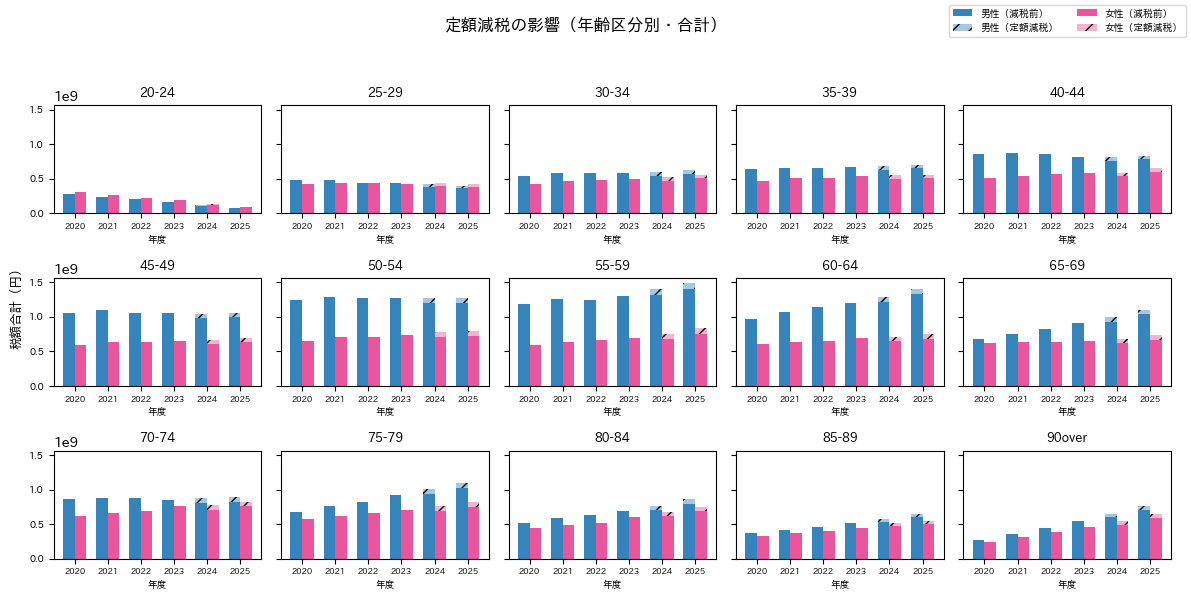

  → 04_datacheck\fig8_3_定額減税_年齢区分別推移_平均.png


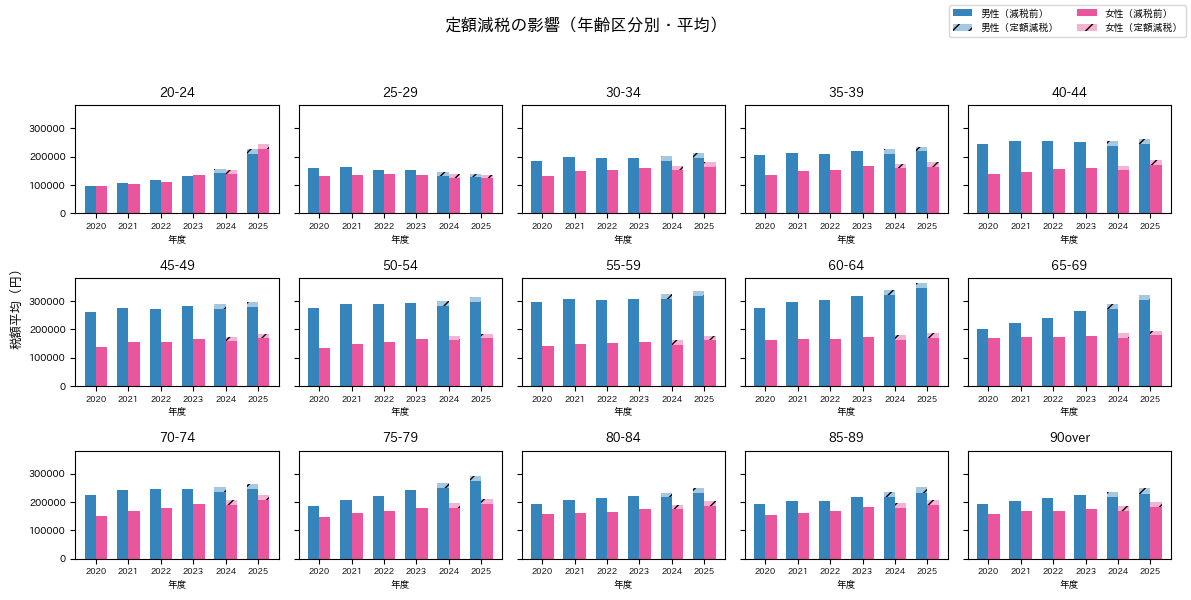

In [28]:
## 税額合計を年齢区分別・年度推移（合計）で積み上げ棒グラフで表示
plot_teigaku_reduction_yearly_by_age(df_mock_teigaku, agg="sum", show=True)
## 税額合計を年齢区分別・年度推移（平均）で積み上げ棒グラフで表示
plot_teigaku_reduction_yearly_by_age(df_mock_teigaku, agg="mean", show=True)

In [29]:
print("Finished all plots")

Finished all plots
